# Interpretation of 3D CNNs for Brain MRI Data Classification


In this notebook, we explore how a simple 3D CNN (PyTorch) makes decisions on Alzheimer’s disease classification using data from Alzheimer’s Disease Neuroimaging Initiative (ADNI) dataset *(ADNI is a global research effort that actively supports the investigation and development of treatments that slow or stop the progression of Alzheimer's disease (AD))* , preprocessed by the [Clinica](https://aramislab.paris.inria.fr/clinica/docs/public/latest/WhatIsClinica/) software platform.

The ADNI study tracks the progression of the disease using biological markers (biomarkers; for example, chemicals found in blood, or changes to the brain observed in MRI and PET scans), together with clinical measures (cognitive and neuropsychological tests), to assess the brain’s structure and function over the course of three disease states (cognitively normal/unimpaired, mild cognitive impairment, dementia).

By proceeding, you confirm you have authorized access to ADNI 1/GO/2/3 Study Data and agree to the data terms and conditions.

Original sourse: https://adni.loni.usc.edu/

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/BIMAI-lab/NEUROML_course/blob/main/seminar9/Seminar9_Interpretation.ipynb)

<h4> Our goal is to study several interpretation techniques for CNNs to assess model reliability on brain MRIs.

If you want to save results to your Google Disk:

```
# use this code
from google.colab import drive
drive.mount('/content/drive')
```



In [9]:
# ATTENTION: follow these instructions if there are no libraries in the environment.
# !pip install nilearn==0.10.4
# !pip install nibabel==5.2.1

In [10]:
# ATTENTION: follow these instructions if there are no libraries in the environment.
# !pip install antspyx
# !pip install torchio

In [3]:
import os
from os import path
import sys
import argparse
import pandas as pd
import numpy as np
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, sampler
import torchvision.transforms as transforms
from scipy.ndimage import gaussian_filter
import abc
import logging
import nibabel as nib
import matplotlib.pyplot as plt
from nilearn import plotting
from tqdm import tqdm

import ants # Python wrapper over ANTs (registration, transformations).
import torchio as tio
from torchio.transforms import HistogramStandardization

In [6]:
import nilearn
nilearn.__version__

'0.10.4'

In [7]:
import nibabel
nibabel.__version__

'5.2.1'

In [4]:
# setting device on GPU if available, else CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

To simplify the workflow and focus on interpretation methods, we will work with a small sample of **10 MRI scans** extracted from the preprocessed ADNI data. Each MRI volume is stored in the NIfTI format (`.nii` or `.nii.gz`), which is a standard in neuroimaging

In [11]:
# !wget -O test_data.zip "https://cloud.appliedai.tech/s/6wXEsjEiJJLRyyA/download?path=%2FSeminar%209&files=test_data.zip"

--2026-08-26 13:47:23--  https://cloud.appliedai.tech/s/6wXEsjEiJJLRyyA/download?path=%2FSeminar%209&files=test_data.zip
Resolving cloud.appliedai.tech (cloud.appliedai.tech)... 195.133.216.210
Connecting to cloud.appliedai.tech (cloud.appliedai.tech)|195.133.216.210|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 898980334 (857M) [application/zip]
Saving to: ‘test_data.zip’

100%[======================================>] 898,980,334 56.8MB/s   in 15s    

2026-08-26 13:47:39 (57.3 MB/s) - ‘test_data.zip’ saved [898980334/898980334]



In [7]:
# !unzip test_data.zip

Archive:  test_data.zip
   creating: test_data/
   creating: test_data/model/
  inflating: test_data/model/model_best.pth.tar  
   creating: test_data/.ipynb_checkpoints/
   creating: test_data/10_sub_for_validation/
  inflating: test_data/10_sub_for_validation/mean_mean_perturb_class1.nii.gz  
   creating: test_data/10_sub_for_validation/sub-ADNI002S4262/
   creating: test_data/10_sub_for_validation/sub-ADNI002S4262/interp_maps/
  inflating: test_data/10_sub_for_validation/sub-ADNI002S4262/interp_maps/sub-ADNI002S4262_ses-M60_grad_cam.nii.gz  
  inflating: test_data/10_sub_for_validation/sub-ADNI002S4262/interp_maps/sub-ADNI002S4262_ses-M60_guided_backprop.nii.gz  
  inflating: test_data/10_sub_for_validation/sub-ADNI002S4262/interp_maps/sub-ADNI002S4262_ses-M60_mean_perturb.nii.gz  
   creating: test_data/10_sub_for_validation/sub-ADNI002S4262/raw_data/
  inflating: test_data/10_sub_for_validation/sub-ADNI002S4262/raw_data/sub-ADNI002S4262_ses-M60_T1w_space-MNI152NLin2009cSym_desc-Cr

#### Quick look at one subject

In [4]:
# --- Configure paths ---
BASE_DIR = Path("test_data/10_sub_for_validation")

# Let's find the first available patient and one T1 volume (preferably M00)
subjects = sorted([p for p in BASE_DIR.iterdir() if p.is_dir() and p.name.startswith("sub-")])
assert subjects, f"Не найдено папок sub-* в {BASE_DIR}"
sub_dir = subjects[0] / "raw_data"

# T1 in MNI space, let's take M00 if there is, otherwise the first alphabetically
t1_files = sorted(sub_dir.glob("*_T1w_space-MNI152NLin2009cSym_desc-Crop_res-1x1x1_T1w.nii.gz"))
assert t1_files, f"Не найдено T1-файлов в {sub_dir}"
t1_m00 = [f for f in t1_files if "_ses-M00_" in f.name]
img_path = t1_m00[0] if t1_m00 else t1_files[0]

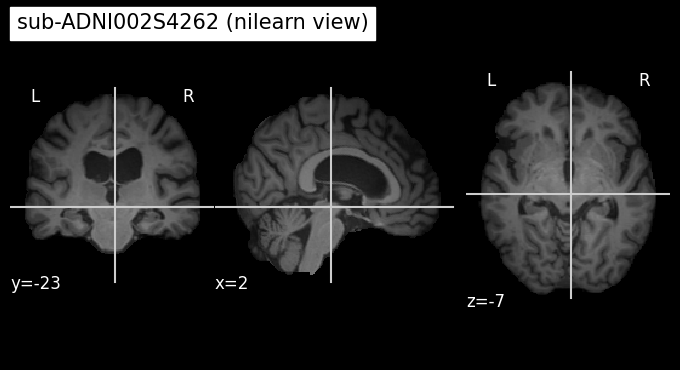

In [5]:
# ---------- Plot: nilearn high-level view ----------
display = plotting.plot_anat(img_path, title=f"{sub_dir.parent.name} (nilearn view)")

## Pipeline with dataset and model

### Writing dataset

`MRIDatasetImage`

Purpose:

    This class standardizes access to MRI data in NIfTI format so that it can be conveniently fed into a PyTorch model.

How it works:

- **CAPS directory (`caps_directory`)**
  Root folder where each subject's data is stored (`sub-XXX/raw_data/*.nii.gz`).

- **TSV table (`data_df`)**
  Contains a list of subjects with columns `participant_id`, `session_id`, `diagnosis`, (+ 'age', 'sex').

- **Main components:**

  1. `__len__` → returns the number of samples in the dataset.
  2. `__getitem__(idx)` → by index finds `participant_id` and `session_id`, loads the corresponding `.nii.gz`: <p>
        converts it to a tensor, applies normalization and augmentations, returns a dictionary.
  3. `diagnosis_code` → dictionary for mapping diagnoses (`CN → 0`, `AD → 1`, …).
  4. `train()` / `eval()` → switches that control the application of augmentations.

In [6]:
# template of the end of filename .nii/.nii.gz
FILENAME_TYPE = '_T1w_space-MNI152NLin2009cSym_desc-Crop_res-1x1x1_T1w'

def get_nii_path(caps_dict, participant_id, session_id, cohort):
    """
    Build path to NIfTI volume:
    <caps>/<participant_id>/raw_data/<participant_id>_<session_id><suffix>.nii.gz
    """
    
    if cohort not in caps_dict.keys():
        raise ValueError('Cohort names in labels and CAPS definitions do not match.')

    base = Path(caps_dict[cohort]) / participant_id / "raw_data"
    filename = f"{participant_id}_{session_id}{FILENAME_TYPE}.nii.gz"
    return str(base / filename)

def get_transforms(mode="image", minmaxnormalization=True, data_augmentation=None):
    """
    Outputs the transformations that will be applied to the dataset
    :param mode: (str) input used by the network. Chosen from ['image', 'patch', 'roi', 'slice'].
    :param minmaxnormalization: (bool) if True will perform MinMaxNormalization
    :param data_augmentation: (list[str]) list of data augmentation performed on the training set.
    :return:
    - container transforms.Compose including transforms to apply in train and evaluation mode.
    - container transforms.Compose including transforms to apply in evaluation mode only.
    """
    augmentation_dict = {"None": None}
    if data_augmentation:
        augmentation_list = [augmentation_dict[augmentation] for augmentation in data_augmentation]
    else:
        augmentation_list = []

    if minmaxnormalization:
        transformations_list = [MinMaxNormalization()]
    else:
        transformations_list = []

    all_transformations = transforms.Compose(transformations_list)
    train_transformations = transforms.Compose(augmentation_list)

    return train_transformations, all_transformations

In [7]:
class ToTensor(object):
    """Convert numpy image to Torch tensor"""

    def __call__(self, image):
        np.nan_to_num(image, copy=False)
        image = image.astype(np.float32, copy=False)
        return torch.from_numpy(image[None, ...])  # add channel C=1
    
class MinMaxNormalization:
    """Normalizes the tensor to the range [0, 1]"""
    
    def __init__(self, eps: float = 1e-6):
        self.eps = eps

    def __call__(self, image):
        return (image - image.min()) / (image.max() - image.min() + self.eps)

class MRIDataset(Dataset):
    """Abstract class for all derived MRIDatasets."""

    def __init__(self, 
                 caps_directory, 
                 data_file,
                 preprocessing, 
                 transformations, 
                 labels,
                 augmentation_transformations=None, 
                 multi_cohort=False):
        """
        Args:
            caps_directory (string): Directory of all the images.
            data_file (string or DataFrame): Path to the tsv file or DataFrame containing the subject/session list.
            preprocessing (string): Defines the path to the data in CAPS.
            train_transformations (callable, optional): Optional transform to be applied only on training mode.
            labels (bool): If True the diagnosis will be extracted from the given DataFrame.
            all_transformations (callable, options): Optional transform to be applied during training and evaluation.
            multi_cohort (bool): If True caps_directory is the path to a TSV file linking cohort names and paths.
        """
        
        # --- configure paths ---
        self.caps_dict = self.create_caps_dict(caps_directory, multi_cohort)
        # --- transformations ---
        self.transformations = transformations
        self.augmentation_transformations = augmentation_transformations
        self.eval_mode = False # manages the application of augmentations
        # --- map diagnosis ---
        self.labels = labels
        self.diagnosis_code = {
            'CN': 0,      # cognitively normal
            'BV': 1,      # Behavioral Variant
            'AD': 1,      # Alzheimer's disease
            'sMCI': 0,    # stable Mild Cognitive Impairment
            'pMCI': 1,    # progressive Mild Cognitive Impairment
            'MCI': 1,     # Mild Cognitive Impairment
            'unlabeled': -1}
        self.preprocessing = preprocessing

        if not hasattr(self, 'elem_index'):
            raise ValueError(
                "Child class of MRIDataset must set elem_index attribute.")
        if not hasattr(self, 'mode'):
            raise ValueError(
                "Child class of MRIDataset must set mode attribute.")

        # --- load and valifate table with samples ---
        if isinstance(data_file, str):
            self.df = pd.read_csv(data_file, sep='\t')
        elif isinstance(data_file, pd.DataFrame):
            self.df = data_file
        else:
            raise Exception('The argument data_file is not of correct type.')

        if not multi_cohort:
            self.df["cohort"] = "single"

        mandatory_col = {"participant_id", "session_id"}
        if self.labels:
            mandatory_col.add("diagnosis")
        if multi_cohort:
            mandatory_col.add("cohort")
        if self.elem_index == "mixed":
            mandatory_col.add("%s_id" % self.mode)

        missing = mandatory_col.difference(self.df.columns)
        if missing:
            raise ValueError(f"Data file has wrong format. Missing columns: {sorted(missing)}")
            
        # number of elements per scan
        self.elem_per_image = self.num_elem_per_image()
        # preload one element to get tensor size
        self.size = self[0]['image'].size()

    def __len__(self):
        return len(self.df) * self.elem_per_image

    @staticmethod
    def create_caps_dict(caps_directory, multi_cohort):
        """Create dict {cohort_name: caps_path}."""
        if not multi_cohort:
            caps_dict = {'single': caps_directory}
        else:
            raise ValueError(f"Expect 'single' cohort in this study.")
        return caps_dict

    def _get_meta_data(self, idx):
        """
        Converts the dataset index into the sample metadata.
        
        Returns: participant, session, cohort, elem_idx, label
        """
        image_idx = idx // self.elem_per_image
        participant = self.df.loc[image_idx, 'participant_id']
        session = self.df.loc[image_idx, 'session_id']
        cohort = self.df.loc[image_idx, 'cohort']

        if self.elem_index is None:
            elem_idx = idx % self.elem_per_image
        elif self.elem_index == "mixed":
            elem_idx = self.df.loc[image_idx, '%s_id' % self.mode]
        else:
            elem_idx = self.elem_index

        if self.labels:
            diagnosis = self.df.loc[image_idx, 'diagnosis']
            label = self.diagnosis_code[diagnosis]
        else:
            label = self.diagnosis_code['unlabeled']

        return participant, session, cohort, elem_idx, label

    def _get_full_image(self):
        """
        Loads the first scan from the table (convenient for debugging/checking the form).
        """
        participant_id = self.df.loc[0, 'participant_id']
        session_id = self.df.loc[0, 'session_id']
        cohort = self.df.loc[0, 'cohort']

        image_path = get_nii_path(self.caps_dict, participant_id, session_id, cohort=cohort)
        image_np = nib.load(image_path).get_fdata()
        image = ToTensor()(image_np)

        return image

    @abc.abstractmethod
    def __getitem__(self, idx):
        """Should return a dictionary with at least the following keys: 'image', 'label', 'participant_id', 'session_id', 'image_path'."""
        pass

    @abc.abstractmethod
    def num_elem_per_image(self):
        """How many items do we give per scan (for slices/patches it would be >1)."""
        pass

    def eval(self):
        self.eval_mode = True
        return self

    def train(self):
        self.eval_mode = False
        return self

In [8]:
class MRIDatasetImage(MRIDataset):
    """A dataset with one MRI volume (NIfTI) → one element"""

    def __init__(self, 
                 caps_directory,
                 data_df,
                 preprocessing=None, 
                 train_transformations=None,
                 labels=True, 
                 all_transformations=None, 
                 multi_cohort=False):
        
        self.elem_index = None
        self.mode = "image" # input used by the network. Chosen from ['image', 'patch', 'roi', 'slice']
        super().__init__(caps_directory, data_df, preprocessing,
                         augmentation_transformations=train_transformations, labels=labels,
                         transformations=all_transformations, multi_cohort=multi_cohort)

    def __getitem__(self, idx):
        participant, session, cohort, _, label = self._get_meta_data(idx)
        image_path =  get_nii_path(self.caps_dict, participant, session, cohort)
        image_nii = nib.load(image_path)
        image_np = image_nii.get_fdata()
        image = ToTensor()(image_np)

        if self.transformations:
            image = self.transformations(image)

        if self.augmentation_transformations and not self.eval_mode:
            image = self.augmentation_transformations(image)

        sample = {'image': image, 
                  'label': label, 
                  'participant_id': participant, 
                  'session_id': session,
                  'image_path': image_path}

        return sample

    def num_elem_per_image(self):
        return 1

<h4> Function for visualization of anatomy / anatomy + interpretation map

In [9]:
def display_interpretation(data_img, interp_img=None, cut_coords=None, threshold=None, name = 'interpretation', save = False):
    """
    Visualizes interpretation map on top of the anatomy data
    - If interp_img=None → draw only the anatomy (plot_anat).
    - If interp_img is set → we apply it as ROI (plot_roi).
    """
    
    fig, axes = plt.subplots(figsize=(12, 5))
    
    # --- background from data_img ---
    bg_arr = np.squeeze(data_img['image']).detach().cpu().numpy()
    assert bg_arr.ndim == 3, f"Ожидаем 3D фон, получили {bg_arr.shape}"
    # --- compile NIfTI with affine = I ---
    bg_nii = nib.Nifti1Image(bg_arr.astype(np.float32), affine=np.eye(4))
    
    if interp_img is None:
        plotting.plot_anat(bg_nii, axes=axes, title=f"{sample.get('participant_id', 'subject')} | {name}")
    
    else:
        # --- interp img to numpy 3D ---
        if isinstance(interp_img, torch.Tensor):
            roi_arr = interp_img.detach().cpu().numpy()
        else:
            roi_arr = np.asarray(interp_img)
        assert roi_arr.shape == bg_arr.shape, f"Размер 3D карты интерпретации {roi_arr.shape} не равен размеру фона"
    
        # --- compile NIfTI with affine = I ---
        interp_nii = nib.Nifti1Image(roi_arr.astype(np.float32), affine=np.eye(4))
    
        # --- draw plot_roi ---
        plotting.plot_stat_map(interp_nii, bg_nii, axes=axes,
                          cut_coords=cut_coords, alpha=0.6,
                          colorbar=True, cmap='jet', threshold=threshold, 
                          title = f"{sample.get('participant_id', 'subject')} | {name}"
        )
    
    if save:
        fig.savefig(f"{name}_map.png", bbox_inches='tight')        

In [10]:
tsv_path = Path('test_data/labels_list') # path to the metadata tables with labels
caps = Path("test_data/10_sub_for_validation") # path .nii.gz files with MRI scans
task_diagnoses = 'AD' # 'CN'
train_transforms, all_transforms = get_transforms(minmaxnormalization=True, data_augmentation=None)

test_diagnosis_path = path.join(tsv_path, task_diagnoses + '.tsv')
test_df = pd.read_csv(test_diagnosis_path, sep='\t')
test_df.reset_index(inplace=True, drop=True)
test_df["cohort"] = "single"
test_df

,participant_id,session_id,diagnosis,age,sex,cohort
0,sub-ADNI002S4262,ses-M60,AD,77.8,F,single
1,sub-ADNI023S0061,ses-M108,AD,86.2,F,single
2,sub-ADNI035S0555,ses-M108,AD,86.5,M,single
3,sub-ADNI037S0467,ses-M108,AD,90.1,F,single
4,sub-ADNI037S4706,ses-M12,AD,61.7,M,single
5,sub-ADNI051S1123,ses-M96,AD,83.8,F,single
6,sub-ADNI114S0166,ses-M108,AD,81.5,F,single
7,sub-ADNI116S1249,ses-M108,AD,80.0,F,single
8,sub-ADNI123S0106,ses-M108,AD,82.2,F,single
9,sub-ADNI137S0972,ses-M96,AD,85.9,M,single


In [11]:
data_test = MRIDatasetImage(caps, data_df=test_df,
                                train_transformations=train_transforms, 
                                all_transformations=all_transforms,
                                labels=True)
print("Dataset size:", len(data_test))

Dataset size: 10


In [12]:
sample = data_test[3]

print("\nSample keys:", sample.keys())
print("Participant:", sample["participant_id"], "| Session:", sample["session_id"])
print("Label:", sample["label"])
print(f"Image path exists: {Path(sample['image_path']).exists()} - {Path(sample['image_path']).name}")

# Let's check the shape and statistics of the image
img = sample["image"]
print("Image shape:", img.shape)   # expect [1, D, H, W]
print("Image dtype:", img.dtype)
print(f"Intensity stats: min={img.min().item():.3f}, max={img.max().item():.3f}")


Sample keys: dict_keys(['image', 'label', 'participant_id', 'session_id', 'image_path'])
Participant: sub-ADNI037S0467 | Session: ses-M108
Label: 1
Image path exists: True - sub-ADNI037S0467_ses-M108_T1w_space-MNI152NLin2009cSym_desc-Crop_res-1x1x1_T1w.nii.gz
Image shape: torch.Size([1, 169, 208, 179])
Image dtype: torch.float32
Intensity stats: min=0.000, max=1.000


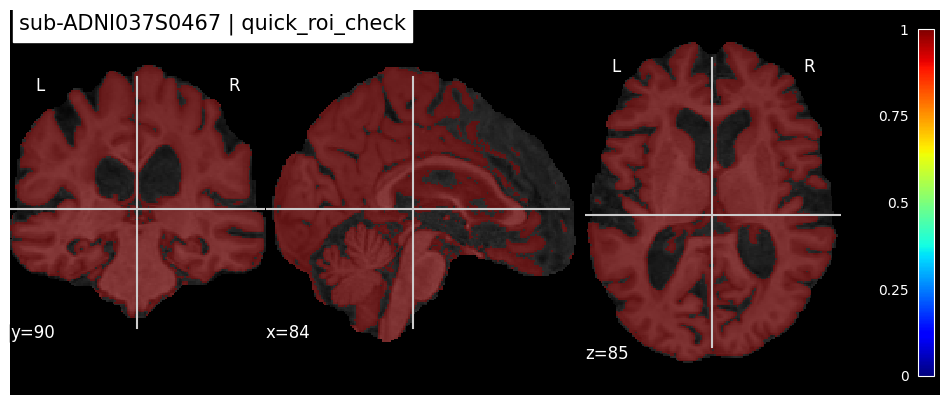

In [13]:
# An example of a "mask" from the interpretation
img3d = sample["image"].squeeze(0).numpy()
m = (img3d > img3d.mean() + 0.5*img3d.std()).astype(np.float32)

# Let's see how the mask is applied (roi mode)
display_interpretation(
    data_img=sample,
    interp_img=m,
    cut_coords=None,
    threshold = 0.0,
    name="quick_roi_check",
    save=False
)

### Define model

Class `Conv5_FC3`

**Task:** binary classification of brain MRI (input format: tensor `[B, 1, D, H, W]`, normalized to `[0, 1]`).

**Architecture:**

- Feature block: 5× (`Conv3d → BatchNorm3d → ReLU → MaxPool3d`), final channels: `1 → 8 → 16 → 32 → 64 → 128`.
- Size fixing (via padding/pooling) → then classifier:
  `Flatten → Dropout → Linear(… → 1300) → ReLU → Linear(1300 → 50) → ReLU → Linear(50 → 2)` (logits).

**Interpretation (Grad-CAM compatibility):**

The model registers a **hook** on the activations of the last convolutional block; gradients are saved via the `get_activations_gradient()` method.

In [14]:
class Conv5_FC3(nn.Module):
    """
    Classifier for a binary classification task
    Image level architecture used on Minimal preprocessing
    """
    def __init__(self, dropout=0.5):
        super(Conv5_FC3, self).__init__()

        self.features = nn.Sequential(
            nn.Conv3d(1, 8, 3, padding=1),
            nn.BatchNorm3d(8),
            nn.ReLU(),
            PadMaxPool3d(2, 2),

            nn.Conv3d(8, 16, 3, padding=1),
            nn.BatchNorm3d(16),
            nn.ReLU(),
            PadMaxPool3d(2, 2),

            nn.Conv3d(16, 32, 3, padding=1),
            nn.BatchNorm3d(32),
            nn.ReLU(),
            PadMaxPool3d(2, 2),

            nn.Conv3d(32, 64, 3, padding=1),
            nn.BatchNorm3d(64),
            nn.ReLU(),
            PadMaxPool3d(2, 2),

            nn.Conv3d(64, 128, 3, padding=1),
            nn.BatchNorm3d(128),
            nn.ReLU(),
            PadMaxPool3d(2, 2),

        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(p=0.5),

            nn.Linear(128 * 6 * 7 * 6, 1300),
            nn.ReLU(),

            nn.Linear(1300, 50),
            nn.ReLU(),

            nn.Linear(50, 2)

        )
        self.gradients = None # hook will put gradients here
        self.flattened_shape = [-1, 128, 6, 7, 6]

    def activations_hook(self, grad):
        self.gradients = grad

    def forward(self, x):
        x = self.features(x)
        if x.requires_grad: # and self.train
            h = x.register_hook(self.activations_hook)
        x = self.classifier(x)

        return x

    def get_activations_gradient(self):
        return self.gradients

    def get_activations(self, x):
        return self.features(x)

class PadMaxPool3d(nn.Module):
    """
    MaxPool3d with left-side padding up to stride multiplicity.
    Padding is defined as (left_w, right_w, top_h, bottom_h, front_d, back_d) — here we pad only "left"/"top"/"front".
    """
    def __init__(self, kernel_size, stride, return_indices=False, return_pad=False):
        super(PadMaxPool3d, self).__init__()
        self.kernel_size = kernel_size
        self.stride = stride
        self.pool = nn.MaxPool3d(kernel_size, stride, return_indices=return_indices)
        self.pad = nn.ConstantPad3d(padding=0, value=0)
        self.return_indices = return_indices
        self.return_pad = return_pad

    def set_new_return(self, return_indices=True, return_pad=True):
        self.return_indices = return_indices
        self.return_pad = return_pad
        self.pool.return_indices = return_indices

    def forward(self, f_maps):
        # calculate size of padding - shape % stride == 0
        coords = [self.stride - f_maps.size(i + 2) % self.stride for i in range(3)]
        coords = [0 if c == self.stride else c for c in coords]
        # order of ConstantPad3d: (W_left, W_right, H_top, H_bottom, D_front, D_back)
        self.pad.padding = (coords[2], 0, coords[1], 0, coords[0], 0)

        if self.return_indices:
            output, indices = self.pool(self.pad(f_maps))

            if self.return_pad:
                return output, indices, (coords[2], 0, coords[1], 0, coords[0], 0)
            else:
                return output, indices

        else:
            output = self.pool(self.pad(f_maps))

            if self.return_pad:
                return output, (coords[2], 0, coords[1], 0, coords[0], 0)
            else:
                return output

## Interpretation methods

In [15]:
def _save_nii(volume, out_path, affine = None):
    """
    Saves a 3D volume as NIfTI. By default affine=I (for visualization).
    """
    if affine is None:
        affine = np.eye(4, dtype=np.float32)
    nib.save(nib.Nifti1Image(volume.astype(np.float32), affine=affine), str(out_path))
    
def get_masks(dataset, model, method='grad_cam', save_masks=True, mean_mask=True):
    """
    Iterates over the dataset by index, computes interpretation maps and saves them as NIfTI alongside the subject's data.
    Returns:
      preds: list of predicted classes
      masks: list of 3D maps (np.ndarray [D,H,W])
      mean_0, mean_1: mean maps for classes 0 and 1 (or None if the class is absent)
    """
    
    device = next(model.parameters()).device
    model.eval()
    
    masks = []
    preds = []
    labels = []
    caps_root = Path(dataset.caps_dict['single']) # dir with subject's folders with raw data
    
    for i in tqdm(range(len(dataset))):
        sample = dataset[i]
        participant, session = sample["participant_id"], sample["session_id"]
        true_label = int(sample["label"])
        labels.append(true_label)
        
        # model prediction
        x = sample["image"].unsqueeze(0).to(device)  # [1,1,D,H,W]
        logits = model(x)
        pred_label = int(logits.argmax(dim=1).item())
        preds.append(pred_label)

        if method == 'grad_cam':
            gc = GradCam(model)
            hm = gc(x, logits)
            
        elif method == 'guided_backprop':
            gbp = GuidedBackprop(model)
            hm = gbp(x)
            
        elif method == 'mean_perturb':
            mp = MeanPerturb()
            hm = mp(x, pred_label, model)
            
        else:
            raise NotImplementedError(f'undefined method {method}') 
            
        masks.append(hm) 
        
        if save_masks:
            # Save newar the subject
            out_dir = caps_root / participant / 'interp_maps'
            out_dir.mkdir(parents=True, exist_ok=True)
            out_path = out_dir / f"{participant}_{session}_{method}.nii.gz"
            _save_nii(hm, out_path)
        
        # clear GPU-memory
        del x, logits
        
    # Average of classes
    mean_0 = mean_1 = None
    if mean_mask:
        vol = np.stack(masks, axis=0)    # [N, D, H, W]
        labels_np = np.asarray(labels)
        if (labels_np == 0).any():
            mean_0 = vol[labels_np == 0].mean(axis=0)
            _save_nii(mean_0, caps_root / f"mean_{method}_class0.nii.gz")
        if (labels_np == 1).any():
            mean_1 = vol[labels_np == 1].mean(axis=0)
            _save_nii(mean_1, caps_root / f"mean_{method}_class1.nii.gz")
        
    return preds, masks, mean_0, mean_1

### Grad-cam

**Idea**: to take the gradients of the target class flowing into the final convolutional layer to produce a heatmap highlighting the important regions in the image to predict the concept.

1. Select the class of interest (target class)
2. Calculate the gradient of the class logit and the activation maps
3. Average over activations using the global average pooling
4. Obtain neuron importance weights  coefficients $α_k^c$ for each map (this weight $α_k^c$ represents a partial linearization of the deep network downstream from $A$, and captures the ‘importance’ of feature map $A^k$ for a target class $c$)
5. Consider a linear combination
6. Apply ReLU
7. Interpolate the heat-map (increase the dimension)

[visualization + math](https://xai-tutorials.readthedocs.io/en/latest/_model_specific_xai/Grad-CAM.html)


In [16]:
class GradCam():
    def __init__(self, model, eps: float = 1e-6):
        self.model = model
        self.eps = eps

    @torch.enable_grad()
    def __call__(self, x: torch.Tensor, logits: torch.Tensor) -> torch.Tensor:
        """
        x:      [B, 1, D, H, W]
        logits: [B, C]
        return: CAM [B, 1, D, H, W] in [0,1]
        """
        # 1) backward of target logit
        self.model.zero_grad()
        target_idx = logits.argmax(dim=1)                          # [B]
        target_logit = logits.gather(1, target_idx.unsqueeze(1))   # [B,1]
        target_logit.sum().backward()                              # scalar

        # 2) activations and it;s gradients (model should save grad hook)
        acts = self.model.get_activations(x).detach()              # [B, K, d, h, w]
        grads = self.model.get_activations_gradient()              # [B, K, d, h, w]

        # 3) channel weights and CAM
        weights = grads.mean(dim=(2, 3, 4), keepdim=True) # pool the gradients across the channels - [B, K, 1, 1, 1]
        cam = (acts * weights).sum(dim=1, keepdim=True) # weight the channels by corresponding gradients - [B, 1, d, h, w]
        cam = F.relu(cam) # relu on top of the heatmap
        cam = cam / (cam.max() + self.eps) # normalize the heatmap

        # 4) upsampling to the input size
        target_spatial = x.shape[-3:] # (D, H, W)
        cam_up = F.interpolate(cam, size=target_spatial, mode="trilinear", align_corners=False) # interpolate the heat-map and project it onto the original image
        return cam_up.squeeze().cpu().numpy()

In [17]:
model = Conv5_FC3().eval()
model.to(device)
model_path = os.path.join('test_data/model', 'model_best.pth.tar')
results = torch.load(model_path, map_location='cuda', weights_only=False)
model.load_state_dict(results['model'])

<All keys matched successfully>

In [18]:
preds, masks, mean_0, mean_1 = get_masks(data_test, model, method='grad_cam', save_masks=False, mean_mask=True)
len(preds), len(masks), masks[0].shape

100%|███████████████████████████████████████████████████████████████████████████████████| 10/10 [00:05<00:00,  1.93it/s]


(10, 10, (169, 208, 179))

#### Look at heatmap for one subject

0. Look at grad_cam for sub-ADNI002S4262 subject


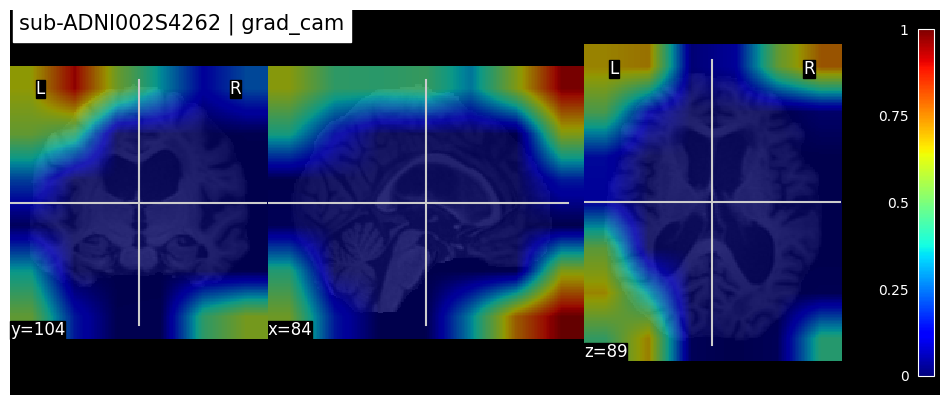

1. Look at grad_cam for sub-ADNI023S0061 subject


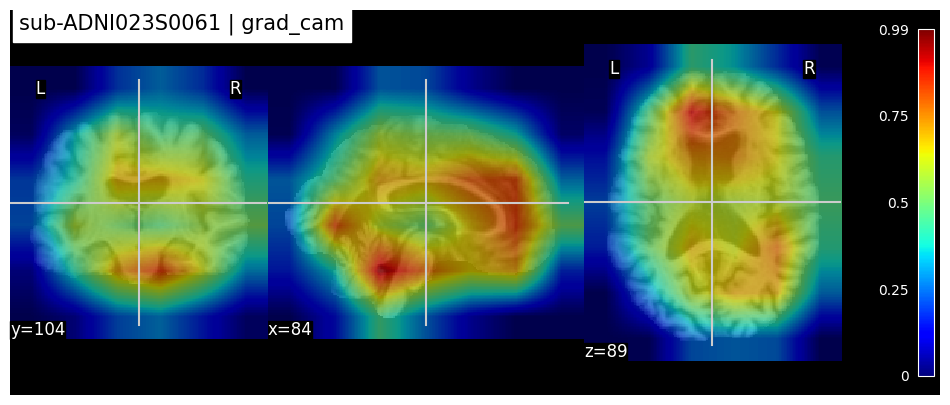

2. Look at grad_cam for sub-ADNI035S0555 subject


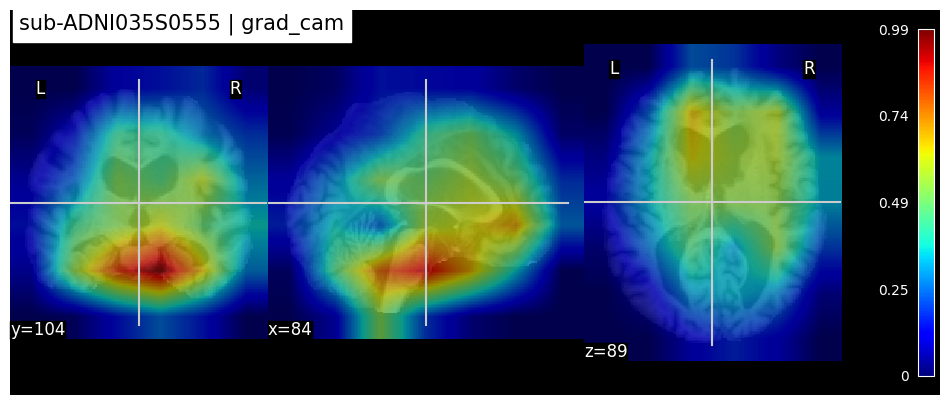

3. Look at grad_cam for sub-ADNI037S0467 subject


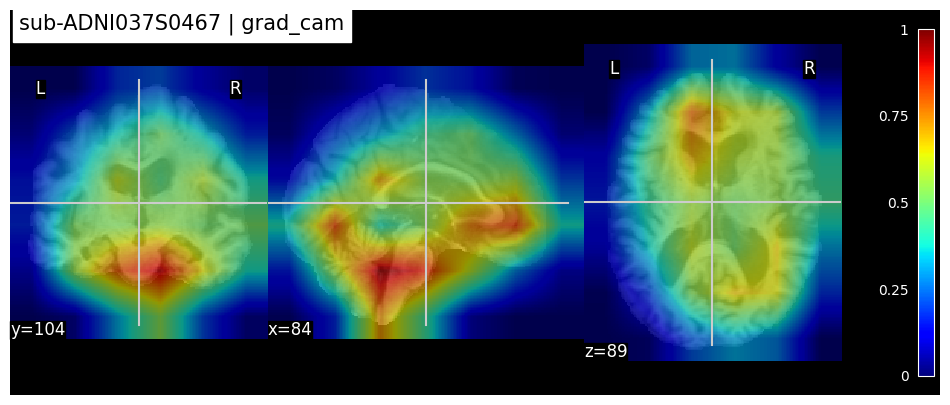

4. Look at grad_cam for sub-ADNI037S4706 subject


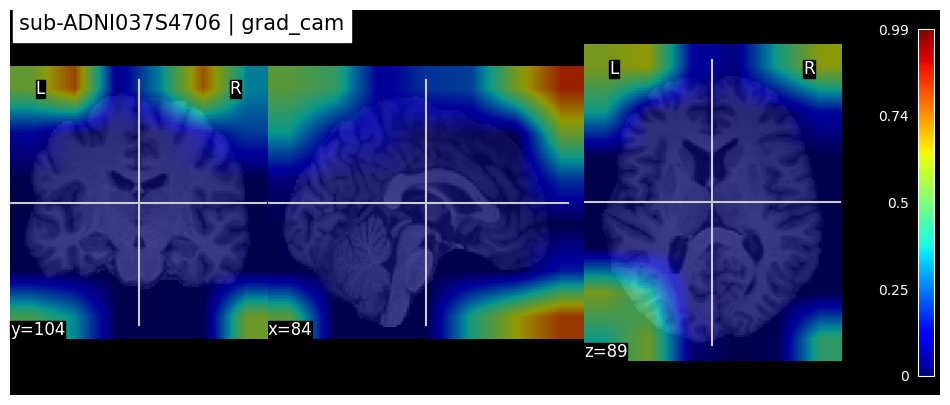

5. Look at grad_cam for sub-ADNI051S1123 subject


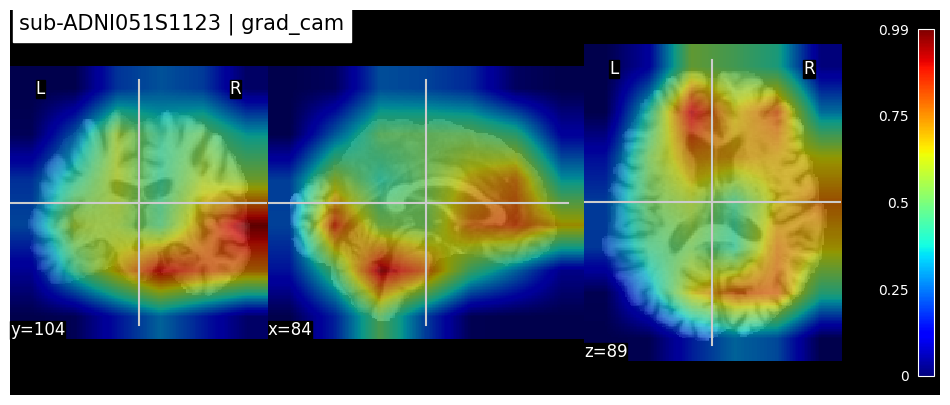

6. Look at grad_cam for sub-ADNI114S0166 subject


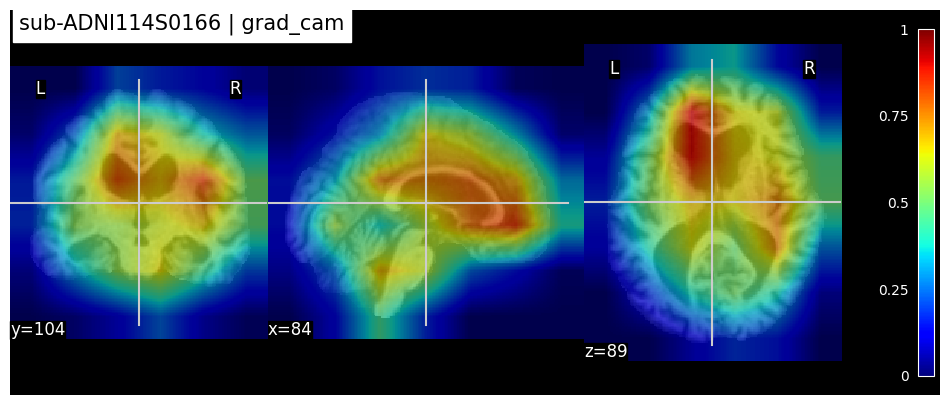

7. Look at grad_cam for sub-ADNI116S1249 subject


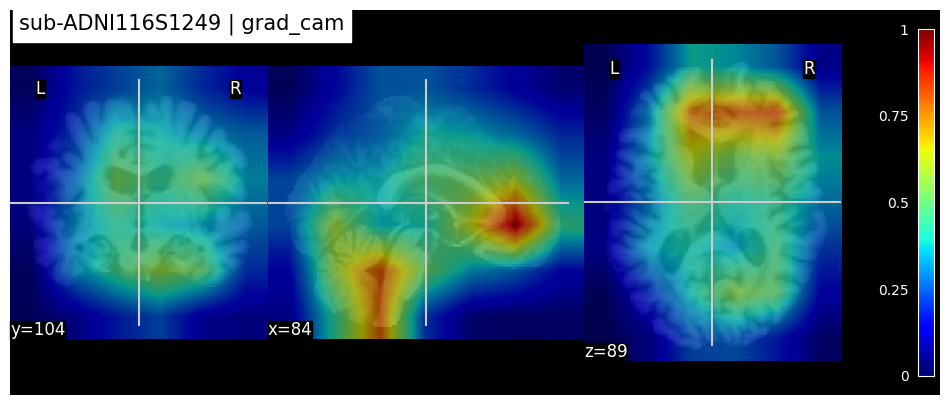

8. Look at grad_cam for sub-ADNI123S0106 subject


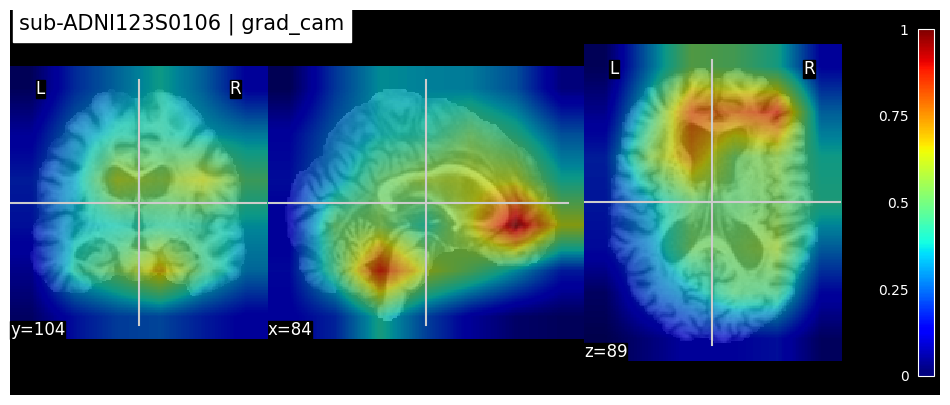

9. Look at grad_cam for sub-ADNI137S0972 subject


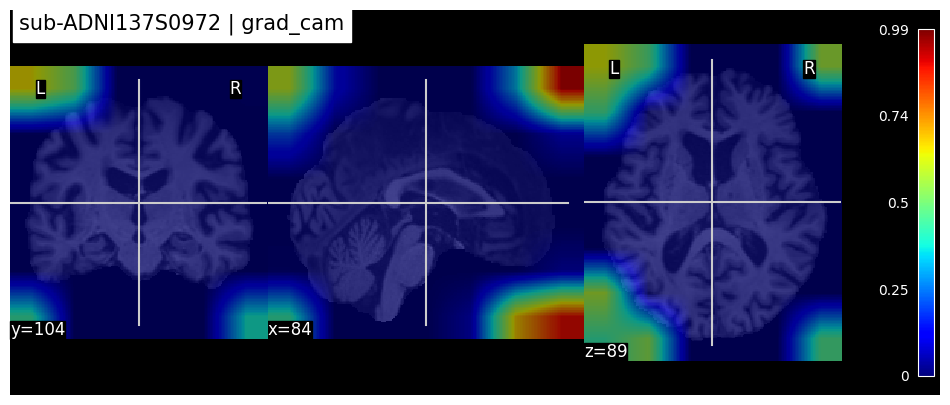

In [ ]:
idx = 6

for idx in range(10):
    sample = data_test[idx]
    participant, session = sample["participant_id"], sample["session_id"]
    print(f"{idx}. Look at grad_cam for {participant} subject")

    # load .nii with grad_cam map
    out_dir = Path(data_test.caps_dict['single']) / participant / 'interp_maps'
    out_path = out_dir / f"{participant}_{session}_grad_cam.nii.gz"       
    img_nii = nib.load(out_path)

    heatmap = img_nii.get_fdata() # masks[idx]
    thr = float(np.quantile(heatmap[heatmap > 0], 0.95)) # 95-й percentile

    display_interpretation(
        data_img=sample,
        interp_img=heatmap,
        cut_coords=(169//2, 208//2, 179//2),
        threshold = None,
        name="grad_cam",
        save=False
    )
    plt.show()

<details>
<summary><strong>Why do some masks look strange?</strong></summary>

👉 Class asymmetry for the binary classifier. 
    
The model is trained to distinguish between `AD (class 1)` and `CN (class 0)`. For class 1, classifier learned the structural signs like hippocampal atrophy, ventricular enlargement. For class 0, the model did **NOT** learn the signs of a "healthy brain" — this is the class of "lack of AD". When the model predicts class 0, gradients flow to any areas that **DO NOT** activate AD patterns, including the edges of the skull and the borders of the brain, where there are sharp intensity fluctuations. 
</details>

#### Look at mean heatmap

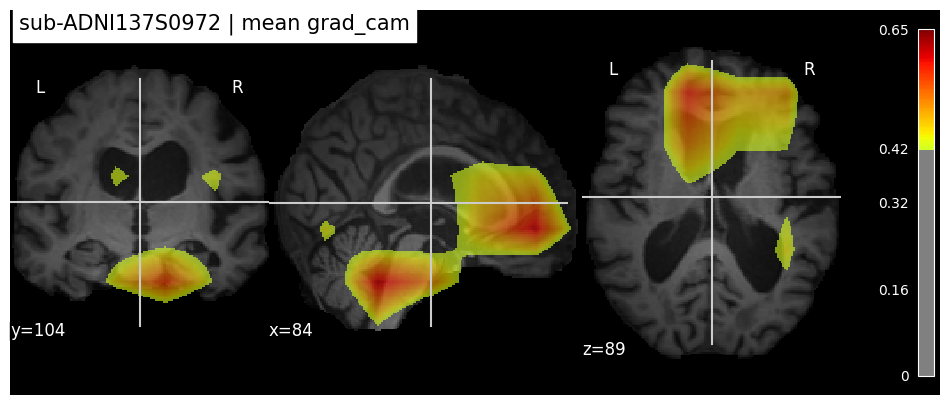

In [ ]:
# load .nii with mean grad_cam map
out_mean_path = Path(data_test.caps_dict['single']) / 'mean_grad_cam_class1.nii.gz'   
img_nii = nib.load(out_mean_path)

heatmap = img_nii.get_fdata()
thr = float(np.quantile(heatmap[heatmap > 0], 0.95))

display_interpretation(
    data_img=data_test[0],
    interp_img=heatmap,
    cut_coords=(169//2, 208//2, 179//2),
    threshold = thr,
    name="mean grad_cam",
    save=False
)
plt.show()

### Guided Backprop

**Idea**: using gradient back propagation as it is except at the ReLU stages. Guided Backpropagation basically combines vanilla backpropagation and DeconvNets when handling the ReLU nonlinearity:
 - Like DeconvNets, in Guided Backpropagation we only backpropagate positive error signals – i.e. we set the negative gradients to zero ([ref](https://arxiv.org/pdf/1412.6806)). This is the application of the ReLU to the error signal itself during the backward pass.
 - Like vanilla backpropagation, we also restrict ourselves to only positive inputs.

Thus, the gradient is “guided” by both the input and the error signal.

[visualization + math](https://leslietj.github.io/2020/07/22/Deep-Learning-Guided-BackPropagation/)

In [22]:
class GuidedBackprop():
    """
    Guided Backprop:
    - attach two hooks to each nn.ReLU: forward (mask input>0) and full_backward (gradient>0 and input>0).
    - compute the input gradient as a saliency map.
    """
    def __init__(self, model, eps: float = 1e-6):
        self.model = model
        self.eps = eps
        self._fwd_hooks = []
        self._bwd_hooks = []
        self._relu_masks = {}  # module -> last forward output (для маски)

    def _register_hooks(self):
        # save «input > 0» using ReLU
        def fwd_hook(module, inp, out):
            self._relu_masks[module] = out

        # applying the GuidedBP rule in the reverse pass
        def bwd_hook(module, grad_input, grad_output):
            # grad_output: tuple with a gradient on the ReLU output
            go = grad_output[0]
            # positive input? (out>0) and a positive gradient?
            pos_inp = (self._relu_masks.get(module, 0) > 0).type_as(go)
            pos_grad = (go > 0).type_as(go)
            new_grad_in = go * pos_inp * pos_grad
            # let's return the gradient to the single ReLU input
            return (new_grad_in,)

        # we'll attach hooks to ALL the ReLUs inside the model
        for m in self.model.modules():
            if isinstance(m, nn.ReLU):
                self._fwd_hooks.append(m.register_forward_hook(fwd_hook))
                self._bwd_hooks.append(m.register_full_backward_hook(bwd_hook))

    def _remove_hooks(self):
        for h in self._fwd_hooks: h.remove()
        for h in self._bwd_hooks: h.remove()
        self._fwd_hooks.clear()
        self._bwd_hooks.clear()
        self._relu_masks.clear()

    def __call__(self, x: torch.Tensor, target=None) -> np.ndarray:
        """
        x: [B,C,D,H,W]
        target: index of the class; if None — use argmax after forward.
        return: np.ndarray [D,H,W] in [0,1]
        """
        self.model.eval()
        self._register_hooks()
        try:
            # 1) «clean» copy of input with requires_grad
            x_req = x.detach().clone().requires_grad_(True)
            
            # 2) forward (x_req!)
            logits = self.model(x_req)
            
            # 3) choose target logit
            if target is None:
                target = int(logits.argmax(dim=1).item())

            # backtracking on the target logit
            self.model.zero_grad()
            logits[0, target].backward()

            # gradient at the entrance → importance map
            grad = x_req.grad.detach()              # [1,1,D,H,W]
            grad = F.relu(grad)                     # cut noise
            grad = grad / (grad.max() + self.eps)   # [0,1]
            return grad.squeeze().cpu().numpy()

        finally:
            self._remove_hooks()

In [23]:
preds, masks, mean_0, mean_1 = get_masks(data_test, model, method='guided_backprop', save_masks=False, mean_mask=True)
len(preds), len(masks), masks[0].shape

100%|███████████████████████████████████████████████████████████████████████████████████| 10/10 [00:04<00:00,  2.16it/s]


(10, 10, (169, 208, 179))

#### Look at heatmap for one subject

In [24]:
model = Conv5_FC3().eval()
model.to(device)
model_path = os.path.join('test_data/model', "model_best.pth.tar")
results = torch.load(model_path, map_location='cuda', weights_only=False)
model.load_state_dict(results['model'])

<All keys matched successfully>

7. Look at grad_cam for sub-ADNI116S1249 subject


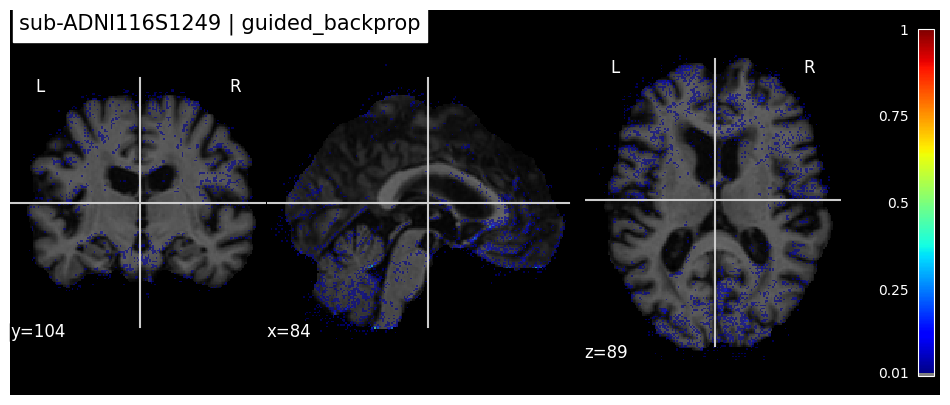

In [26]:
idx = 7

sample = data_test[idx]
participant, session = sample["participant_id"], sample["session_id"]
print(f"{idx}. Look at grad_cam for {participant} subject")

# load .nii with grad_cam map
out_dir = Path(data_test.caps_dict['single']) / participant / 'interp_maps'
out_path = out_dir / f"{participant}_{session}_guided_backprop.nii.gz"       
img_nii = nib.load(out_path)

gb_map = img_nii.get_fdata() # masks[idx]
thr = float(np.quantile(gb_map[gb_map > 0], 0.9))

display_interpretation(
    data_img=sample,
    interp_img=gb_map,
    cut_coords=(169//2, 208//2, 179//2),
    threshold = thr,
    name="guided_backprop",
    save=False
)
plt.show()

#### Look at mean heatmap

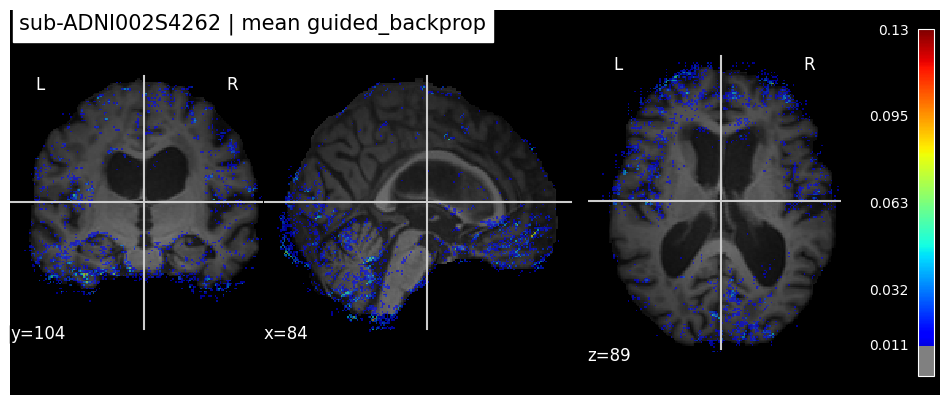

In [28]:
sample = data_test[0]

# load .nii with mean guided_backprop map
out_mean_path = Path(data_test.caps_dict['single']) / 'mean_guided_backprop_class1.nii.gz'   
img_nii = nib.load(out_mean_path)

heatmap = img_nii.get_fdata()
thr = float(np.quantile(heatmap[heatmap > 0], 0.95))

display_interpretation(
    data_img=sample,
    interp_img=heatmap,
    cut_coords=(169//2, 208//2, 179//2),
    threshold = thr,
    name="mean guided_backprop",
    save=False
)
plt.show()

### Mean Perturbations

This is a variant of "meaningful perturbations" ([ref](https://arxiv.org/pdf/1704.03296)): we optimize a **mask** $m\in[0,1]^{D\times H\times W}$ so that when part of the image is replaced by a blurred background, the **model's score for the target class decreases**, while the mask stays **smooth** and (depending on the formulation) **not too large/small**.

The code uses a **"preservation mask"**: the model input is constructed as

$$
x_{\text{pert}} = m \odot x + (1-m)\odot \text{blur}(x)
$$

Then the following loss functional is minimized:

$$
\mathcal{L}(m)= \underbrace{\frac{1}{R}\sum_{r=1}^R\max( s(f(x_{\text{pert}}^r)) - 0.05,\; 0)}_{\text{reduce target class score (with jitter)}}\; +\; 
\underbrace{w(t)\cdot\Big(\lambda_1\cdot \|1-m\|_1 + \lambda_2\cdot \text{TV}(m)\Big)}_{\text{regularization: compactness/smoothness}}
$$

where $s(\cdot)$ is the chosen "class probability scorer", $w(t)$ is a "warm-up" regularization ramp, and $\text{TV}$ is Total Variation regularization.

At the end, **$1-m$** is returned — i.e., the "map of the removed (important) region".

In [29]:
from torch.optim import Adam

# =========================
# AUXILIARY FUNCTIONS
# =========================
def jittering(img: torch.Tensor, jit: int):
    """
    Random shift of the volume via symmetric padding and crop back.
    img:  Tensor of shape [C, D, H, W]
    jit:  max shift in voxels
    """

    C, D, H, W = img.shape
    # Padding: the order of pad arguments in torch = (Wl, Wr, Hl, Hr, Dl, Dr)
    img_pad = F.pad(img, (jit, jit, jit, jit, jit, jit), mode="constant", value=0)

    # Случайные смещения в пределах [0, jit]
    jD = int(torch.randint(low=0, high=jit + 1, size=(1,)).item())
    jH = int(torch.randint(low=0, high=jit + 1, size=(1,)).item())
    jW = int(torch.randint(low=0, high=jit + 1, size=(1,)).item())

    # Crop back to the original size
    img_jit = img_pad[:, jD:jD + D, jH:jH + H, jW:jW + W]
    return img_jit

def upsample(mask: torch.Tensor, img_size):
    """
    Upsample mask to the spatial size of the image.
    """
    x = F.interpolate(mask, size=img_size, mode='trilinear', align_corners=False)
    return x

def tv_norm(x: torch.Tensor, beta: float = 1.0):
    """
    Total Variation (anisotropic) for a 3D mask.
    """
    d1 = torch.mean(torch.abs(x[:, :, :-1, :, :] - x[:, :, 1:, :, :]).pow(beta))
    d2 = torch.mean(torch.abs(x[:, :, :, :-1, :] - x[:, :, :, 1:, :]).pow(beta))
    d3 = torch.mean(torch.abs(x[:, :, :, :, :-1] - x[:, :, :, :, 1:]).pow(beta))
    return d1 + d2 + d3
    
class GaussianFilter(nn.Module):
    """
    Convolutional Gaussian filter (3D), kernel is recomputed by sigma.
    """
    def __init__(self, k_size: int, g_filter=gaussian_filter):
        super().__init__()
        pad = (k_size - 1) // 2
        self.k_size = int(k_size)
        self.g_filter = g_filter
        self.conv = nn.Conv3d(1, 1, self.k_size, padding=(pad, pad, pad), bias=None)
        # we will set the weights manually, there is no need to train
        for p in self.conv.parameters():
            p.requires_grad = False

    def forward(self, x: torch.Tensor, sigma: float):
        # build kernel
        n = np.zeros((self.k_size, self.k_size, self.k_size), dtype=np.float32)
        center = self.k_size // 2
        n[center, center, center] = 1.0
        k = self.g_filter(n, sigma=float(sigma))[None, None, :, :, :]  # [1,1,K,K,K]
        self.conv.weight.data = torch.from_numpy(k).to(x.device)
        return self.conv(x)

# =========================
# THE MAIN CLASS OF THE METHOD
# =========================
class MeanPerturb():
    """
    Meaningful Perturbations.
    Idea: optimize a mask m in [0,1] so that replacing the (1-m) part of the image with a blurred version
    causes the model's confidence in the target class to drop, while m stays smooth.
    """
    def __init__(self,
                 mask_scale: int = 4, # the initial resolution of the mask (in mask_scale times smaller on each axis)
                 blur_img: float = 10.0, # sigma for blurring the image
                 blur_mask: float = 2.0, # sigma for smoothing the mask
                 max_iter: int = 300, # number of iterations
                 l1_coef: float = 3.0, # coef. L1 reg-ii
                 tv_coef: float = 1.0, # coef. TV registration
                 tv_beta: float = 3.0, # degree of smoothness
                 rep: int = 9, # number of jitters per iteration
                 jit: int = 5, # max. shift (voxels)
                 k_size: int = 5,
                 lr: float = 1e-3):
        
        self.lr = lr
        self.mask_scale = int(mask_scale)
        self.blur_img = float(blur_img)
        self.blur_mask = float(blur_mask)
        self.max_iter = int(max_iter)
        self.l1_coef = float(l1_coef)
        self.tv_coef = float(tv_coef)
        self.tv_beta = float(tv_beta)
        self.rep = int(rep)
        self.jit = int(jit)
        self.filter_gaus = GaussianFilter(int(k_size), gaussian_filter)
    
    def _score_prob(self, logits: torch.Tensor, target_idx: int):
        """
        For stability, we use softmax over classes, taking the probability of target.
        """
        # Softmax saturates quickly → the gradient is weak. You can optimize logits or margins.
        #     logits_prob = logits[0, target_cls]
        #     margin_prob = logits[0, target_cls] - torch.max(logits[0, other_classes])
        probs = torch.softmax(logits, dim=1)
        return probs[0, target_idx]

    def __call__(self, img, target_cls, model):
        """
        Main mask optimization loop.
        img:        [1, C, D, H, W] (normalized input, on the same device as the model)
        target_cls: index of the target class (usually the current predicted one)
        model:      torch.nn.Module
        """
        device = img.device
        model.eval()
        # with loss.backward() gradients will be counted only by mask
        for p in model.parameters():
            p.requires_grad_(False)
        
        # remove batch dim → [C, D, H, W]
        img_ = img.squeeze(0) 
        C, D, H, W = img_.shape
        
        # Initializing a mask on a coarse grid
        mD, mH, mW = D // self.mask_scale, H // self.mask_scale, W // self.mask_scale
        mask = torch.ones((1, C, mD, mH, mW), device=device, requires_grad=True)
        
        optimizer = Adam([mask], lr=self.lr, betas=(0.9, 0.99), amsgrad=True, weight_decay=1e-4)
        # In this cycle, "epoch" = one iteration, so StepLR calls step() every step.
        scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.1)
        
        # warming up the regularization: the first ~ 20% of the steps are less punishing for the shape of the mask
        ramp_end = max(1, self.max_iter // 5)
        
        best_loss, best_mask, gt_class_prob = float('inf'), None, None
        for epoch in tqdm(range(self.max_iter), desc="MeanPerturb", leave=False):
            # 1) upsampling + smooth mask
            mask_up = upsample(mask, img_size=(D, H, W))             
            mask_up = self.filter_gaus(mask_up, self.blur_mask)
            mask_up = mask_up.clamp(0, 1)

            # 2) accumulate the predictive part of the loss on several jitters
            total_pred_loss = 0.0
            for _ in range(self.rep):
                img_jit = jittering(img_, self.jit)                 
                img_t = img_jit.unsqueeze(0).to(device)             

                # Blurring the image
                blur = self.filter_gaus(img_t, self.blur_img)        # [1,C,D,H,W]

                # Mixing: m * x + (1-m) * blur(x)
                perturbed = img_t * mask_up + blur * (1.0 - mask_up)

                # model run
                logits = model(perturbed.float())                     # [1, num_classes]

                # We want the probability of the target class to be <= 0.05
                prob = self._score_prob(logits, target_cls) 
                # total_pred_loss = total_pred_loss + F.relu(prob - 0.05)
                total_pred_loss = total_pred_loss + prob

                # clean GPU mem
                del img_t, blur, perturbed, logits, prob

            # 3) regularization: L1 to (1 - mask) + TV(mask_up)
            reg_l1 = self.l1_coef * torch.mean(torch.abs(1.0 - mask))
            reg_tv = self.tv_coef * tv_norm(mask_up, self.tv_beta)
            # the weight of the regularization increases smoothly from 0 to 1
            rw = 1.0 if epoch >= ramp_end else (epoch / float(ramp_end))
            loss = total_pred_loss / float(self.rep) + rw * (reg_l1 + reg_tv)

            # tracking the best mask after a small warm-up (as in the source)
            if epoch > 50 and loss.item() <= best_loss:
                best_loss = loss.item()
                best_mask = mask.detach().clone()

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            # scheduler.step()
            
            # Let's see how the loss, the probability of the target class, and the member of the register change.
            # if epoch % 25 == 0:
            #     with torch.no_grad():
            #         # gnorm = mask.grad.norm().item() if mask.grad is not None else float('nan')
            #         print(f"epoch {epoch:03d} | loss={loss.item():.4f} | pred_part={float(total_pred_loss/self.rep):.4f} | reg={float(rw*(reg_l1+reg_tv)):.4f}")

            # mask borders
            with torch.no_grad():
                mask.clamp_(0.0, 1.0)

        # If no iteration has improved, we use the current mask
        if best_mask is None:
            best_mask = mask.detach()
            
        # return the "importance" as (1 - best_mask), upsampled to the original size.
        res_mask = upsample(1.0 - best_mask, img_size=(D, H, W)) 
        res = res_mask.squeeze()
        res = res.clamp(0.0, 1.0)
        return res.detach().cpu().numpy().astype(np.float32)       

In [30]:
model = Conv5_FC3().eval()
model.to(device)
model_path = os.path.join('test_data/model', "model_best.pth.tar")
results = torch.load(model_path, map_location='cuda', weights_only=False)
model.load_state_dict(results['model'])

<All keys matched successfully>

In [14]:
# import gc
# torch.cuda.empty_cache()
# gc.collect()

In [110]:
# free = torch.cuda.mem_get_info()[0] / 1024 ** 3
# total = torch.cuda.mem_get_info()[1] / 1024 ** 3
# print(f'VRAM: {total - free:.2f}/{total:.2f}GB\t')

In [ ]:
preds, masks, mean_0, mean_1 = get_masks(data_test, model, method='mean_perturb', save_masks=True, mean_mask=True)
len(preds), len(masks), masks[0].shape

3. Look at grad_cam for sub-ADNI037S0467 subject
test_data/10_sub_for_validation/sub-ADNI037S0467/interp_maps/sub-ADNI037S0467_ses-M108_mean_perturb.nii.gz


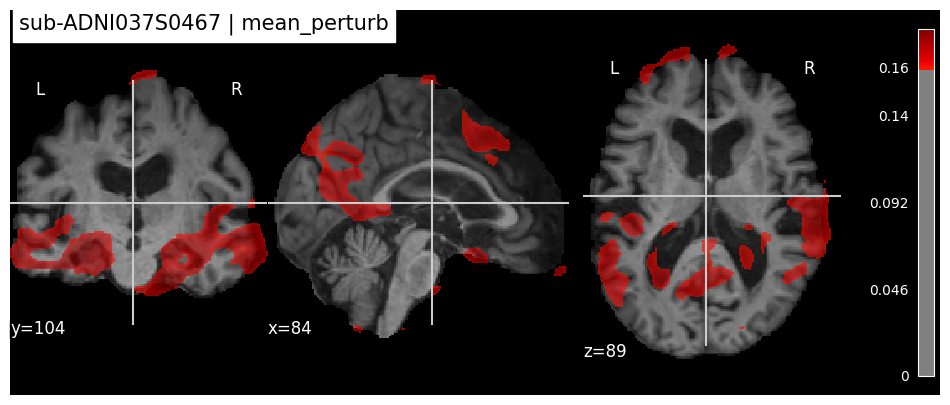

In [31]:
idx = 3

sample = data_test[idx]
participant, session = sample["participant_id"], sample["session_id"]
print(f"{idx}. Look at grad_cam for {participant} subject")

# load .nii with grad_cam map
out_dir = Path(data_test.caps_dict['single']) / participant / 'interp_maps'
out_path = out_dir / f"{participant}_{session}_mean_perturb.nii.gz"   
print(out_path)    
img_nii = nib.load(out_path)

heatmap = img_nii.get_fdata() # masks[idx]
thr = float(np.quantile(heatmap[heatmap > 0], 0.95))

display_interpretation(
    data_img=sample,
    interp_img=heatmap,
    cut_coords=(169//2, 208//2, 179//2),
    threshold = thr,
    name="mean_perturb",
    save=False
)
plt.show()

<h4> A quick sanity-check

Take the top 10% of voxels in the resulting mask and actually "turn them off" in the original image (replace with blur); make sure that the prediction drops noticeably. 

This will confirm that this areas are really "important":

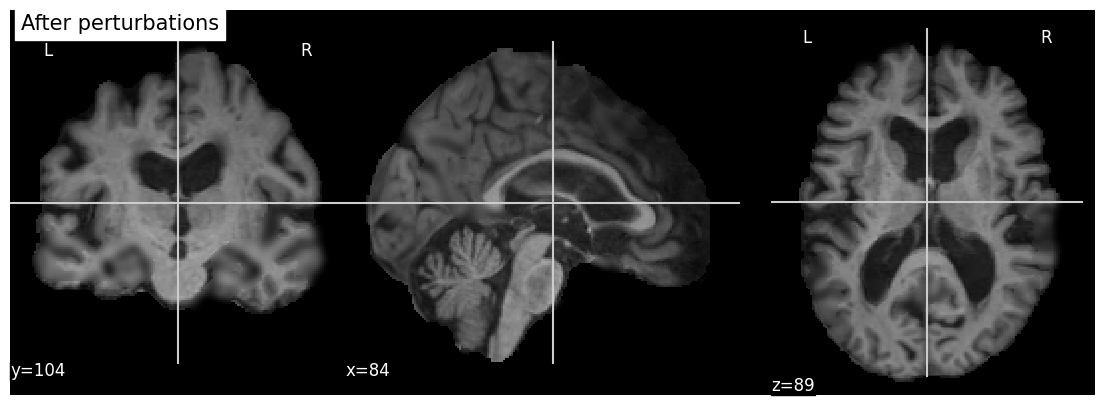

Logits before perturabtions: tensor([[-2.3791,  1.7910]], device='cuda:0') and after:tensor([[ 7.4398, -4.5002]], device='cuda:0')


In [32]:
mp = MeanPerturb()
x = sample['image'].unsqueeze(0).to(device)

# heatmap = masks_perturb
del_region = (heatmap > thr).astype(np.float32)

blur = mp.filter_gaus(x, sigma=mp.blur_img)
x_del = x * (1 - torch.from_numpy(del_region)[None,None].to(device)) + blur * torch.from_numpy(del_region)[None,None].to(device)

logits_before = model(x)
logits_after  = model(x_del)

# Visualization of anatomy after transformation
fig, axes = plt.subplots(1, 1, figsize=(14, 5))
bg_after  = nib.Nifti1Image(x_del.squeeze().detach().cpu().numpy().astype(np.float32), affine=np.eye(4))
plotting.plot_anat(bg_after, axes=axes, cut_coords=(169//2, 208//2, 179//2), title=f"After perturbations")
plt.show()

print(f"Logits before perturabtions: {logits_before.data} and after:{logits_after.data}")

### Difference between brains

`Hypothesis: Difference between AD and CN brains`

Alzheimer’s Disease (AD) is typically associated with **loss of brain tissue** (atrophy), especially in hippocampal and cortical regions.  
This means that on an MRI scan:

- In AD patients: enlarged ventricles, and reduced cortical/hippocampal volume.  
- In CN (cognitively normal) subjects: more intact gray/white matter tissue. 

<img src="https://avatars.mds.yandex.net/i?id=16aa3e6fc2cd9c461c51cd3b28d22484_l-4935265-images-thumbs&n=13" width="600" />

To explore this, we align (register) and normalize the intensities of MRI scans from an cognitively normal (CN) subject and AD subject.  
By subtracting the AD image from the CN image, we expect that:

- **Positive values (CN brighter than AD)** will highlight regions where healthy tissue is preserved in CN but reduced in AD.  
- **Near-zero or negative values** may correspond to CSF spaces or areas without major structural difference.

This subtraction is not a clinical diagnostic tool, but a simple way to visualize hypothesized structural differences between AD and CN after preprocessing.

In [75]:
def register_and_save(moving_path, fixed_path, out_path, tx='Rigid'):
    """
    Registers moving → fixed, saves result to out_path.
    tx: 'Rigid' | 'Affine' | 'SyN'
    """
    fixed  = ants.image_read(str(fixed_path))
    moving = ants.image_read(str(moving_path))
    regs   = ants.registration(fixed=fixed, moving=moving, type_of_transform=tx)
    moved  = ants.apply_transforms(fixed=fixed, moving=moving, transformlist=regs['fwdtransforms'])
    ants.image_write(moved, str(out_path), ri=False)
    
    return out_path

def hist_std_pair(paths, out_prefix='hist_'):
    """
    Learn landmarks from paths data (list of files), apply to all, save alongside.
    Returns a list of paths to standardized files.
    """
    paths = list(map(str, paths))
    landmarks = HistogramStandardization.train(paths)
    hs = tio.HistogramStandardization({'mri': landmarks})

    out_paths = []
    for p in paths:
        subj = tio.Subject(mri=tio.ScalarImage(p))
        res  = hs(subj)
        out_path = Path(p).with_name(out_prefix + Path(p).name)
        res.mri.save(str(out_path))
        out_paths.append(out_path)
        
    return out_paths

def compute_diff(cn_path, ad_path, mode='pos', smooth=0.0):
    """
    Returns a NIfTI with the difference CN - AD, optionally smoothed.
    mode: 'pos' (keep only >0), 'neg' (keep only <0, sign-inverted), 'abs' (absolute value)
    smooth: sigma for Gaussian (in voxels)
    """
    cn_img = nib.load(str(cn_path))
    ad_img = nib.load(str(ad_path))
    cn_np  = np.asarray(cn_img.dataobj, dtype=np.float32)
    ad_np  = np.asarray(ad_img.dataobj, dtype=np.float32)

    diff = cn_np - ad_np
    if mode == 'pos':
        diff = np.where(diff > 0, diff, 0.0)
    elif mode == 'neg':
        diff = np.where(diff < 0, -diff, 0.0)
    elif mode == 'abs':
        diff = np.abs(diff)
    else:
        raise ValueError("mode must be 'pos'|'neg'|'abs'")

    if smooth and smooth > 0:
        diff = gaussian_filter(diff, sigma=float(smooth))

    return nib.Nifti1Image(diff, affine=ad_img.affine)

Merge tables with metadata for CN and AD scans

In [82]:
tsv_path = Path('test_data/labels_list') # path to the metadata tables with labels
caps = Path("test_data/10_sub_for_validation") # path .nii.gz files with MRI scans

task_diag_dfs = []
for task_diag in ['CN', 'AD',]:
    test_df = pd.read_csv(path.join(tsv_path, task_diag + '.tsv'), sep='\t')
    test_df.reset_index(inplace=True, drop=True)
    task_diag_dfs.append(test_df)
    
merged_df = task_diag_dfs[0].merge(task_diag_dfs[1], on='participant_id', suffixes=['_CN', '_AD'])
merged_df

,participant_id,session_id_CN,diagnosis_CN,age_CN,sex_CN,session_id_AD,diagnosis_AD,age_AD,sex_AD
0,sub-ADNI002S4262,ses-M00,CN,72.8,F,ses-M60,AD,77.8,F
1,sub-ADNI023S0061,ses-M00,CN,77.0,F,ses-M108,AD,86.2,F
2,sub-ADNI035S0555,ses-M00,CN,77.0,M,ses-M108,AD,86.5,M
3,sub-ADNI037S0467,ses-M00,CN,81.1,F,ses-M108,AD,90.1,F
4,sub-ADNI037S4706,ses-M48,CN,64.7,M,ses-M12,AD,61.7,M
5,sub-ADNI051S1123,ses-M00,CN,75.8,F,ses-M96,AD,83.8,F
6,sub-ADNI114S0166,ses-M00,CN,72.5,F,ses-M108,AD,81.5,F
7,sub-ADNI116S1249,ses-M00,CN,70.8,F,ses-M108,AD,80.0,F
8,sub-ADNI123S0106,ses-M36,CN,76.2,F,ses-M108,AD,82.2,F
9,sub-ADNI137S0972,ses-M00,CN,77.9,M,ses-M96,AD,85.9,M


Load brain MRIs for AD and CN (healthy). Register CN (healthy brain) -> AD

In [83]:
p_idx = 1
# define paths
participant_id = merged_df.iloc[p_idx].participant_id
sess_id_CN, sess_id_AD = merged_df.loc[p_idx].session_id_CN, merged_df.iloc[p_idx].session_id_AD
base_dir = Path('test_data/10_sub_for_validation') / str(participant_id) / "raw_data"

cn_path = base_dir / f"{participant_id}_{sess_id_CN}{FILENAME_TYPE}.nii.gz"
ad_path = base_dir / f"{participant_id}_{sess_id_AD}{FILENAME_TYPE}.nii.gz"
cn_path.name, ad_path.name

('sub-ADNI023S0061_ses-M00_T1w_space-MNI152NLin2009cSym_desc-Crop_res-1x1x1_T1w.nii.gz',
 'sub-ADNI023S0061_ses-M108_T1w_space-MNI152NLin2009cSym_desc-Crop_res-1x1x1_T1w.nii.gz')

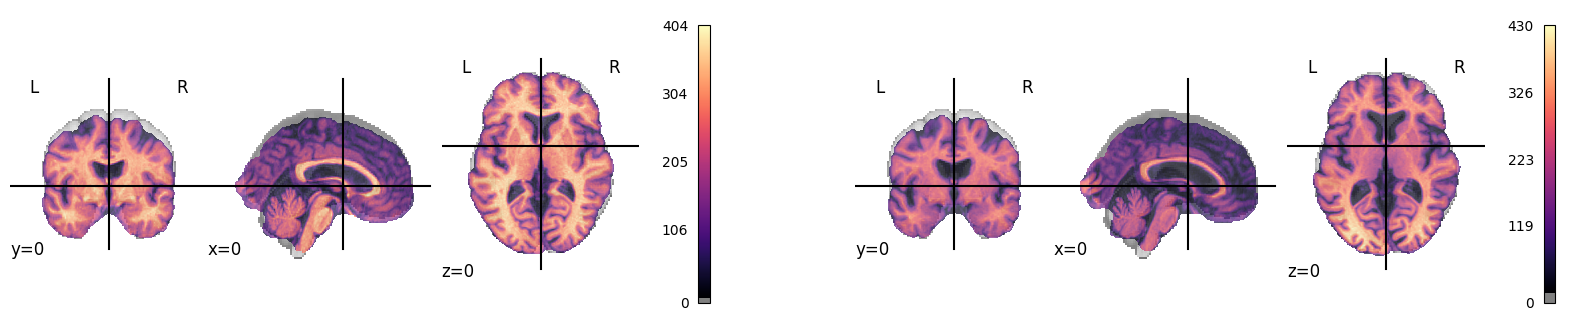

In [84]:
fig, axes = plt.subplots(1, 2, figsize=(20, 4))
plotting.plot_roi(roi_img=cn_path, axes=axes[0], cut_coords=(0, 0, 0), alpha=0.7, colorbar=True, cmap='magma')
plotting.plot_roi(roi_img=ad_path, axes=axes[1], cut_coords=(0, 0, 0), alpha=0.7, colorbar=True, cmap='magma')

In [85]:
# 1) CN → AD
out_path = base_dir / f"{participant_id}_cn_to_ad_rigid.nii.gz"
cn_reg = register_and_save(cn_path, ad_path, out_path=out_path, tx='Rigid')

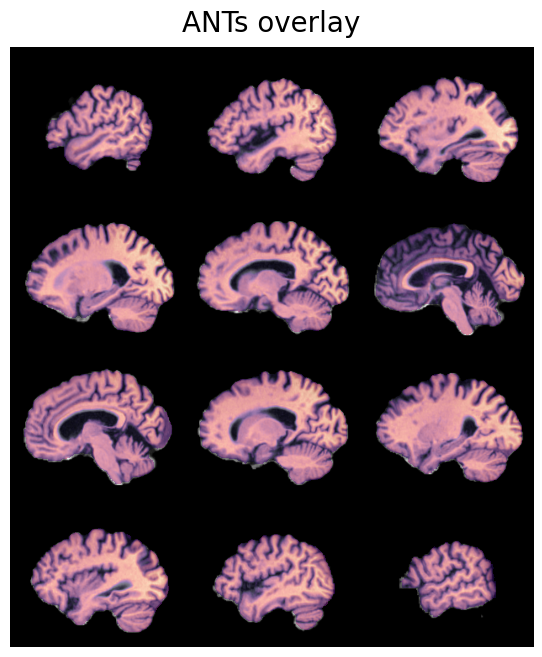

In [86]:
fixed  = ants.image_read(str(out_path)) # cn_path
moving = ants.image_read(str(ad_path))
# superimposing moving onto fixed (gray background, overlay color)
ants.plot(fixed, overlay=moving, axis=0, overlay_cmap='magma', overlay_alpha=0.5, title='ANTs overlay') # axis = 0 | 1 | 2

> **Note on registration:** both CN and AD scans are already in **MNI template space** (`space-MNI152NLin2009cSym`), meaning they were spatially normalized to the same coordinate grid during preprocessing. Rigid registration (`tx='Rigid'`) between them finds only minimal corrections (near-identity transform), so the registered CN looks almost identical to the original. For fine nonlinear alignment between the CN and AD anatomy, try `tx='SyN'` instead — this will capture local deformations (atrophy, ventricular enlargement) at the cost of longer runtime.

Apply histogram standardization to both scans and save

In [47]:
# 2) Standardization of pair histograms
ad_std, cn_std = hist_std_pair([ad_path, cn_reg], out_prefix='hist_')

100%|█████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:00<00:00,  3.20it/s]


Take the scans after standardization and visualize

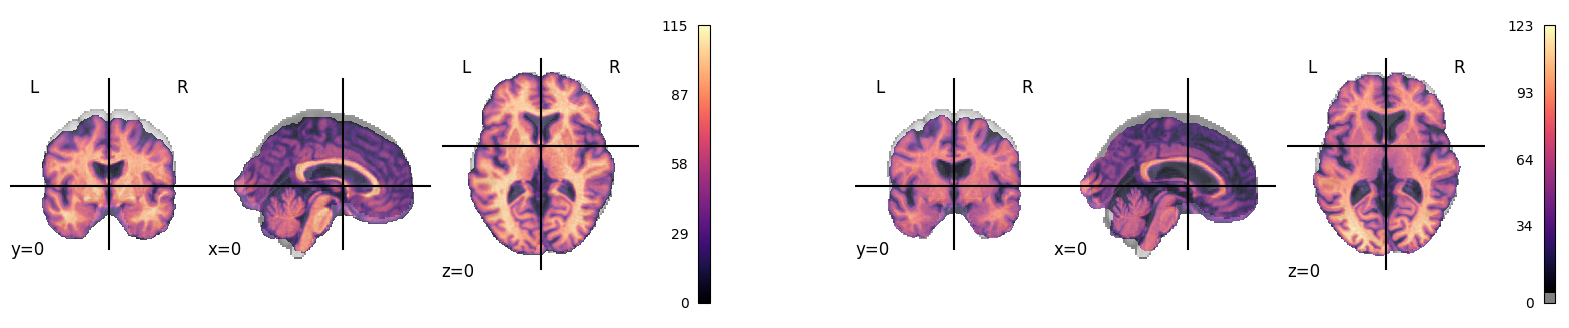

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(20, 4))
plotting.plot_roi(roi_img=cn_std, axes=axes[0], cut_coords=(0, 0, 0), alpha=0.7, colorbar=True, cmap='magma')
plotting.plot_roi(roi_img=ad_std, axes=axes[1], cut_coords=(0, 0, 0), alpha=0.7, colorbar=True, cmap='magma')

Subtract the AD scan values from the healthy scan

Idea: AD MRIs will show clear brain changes — ventricular narrowing (to be refined)

In [49]:
# 3) Difference (positive part of CN-AD), easy smoothing
diff_pos = compute_diff(cn_std, ad_std, mode='pos', smooth=0.0)
diff_pos.shape

(169, 208, 179)

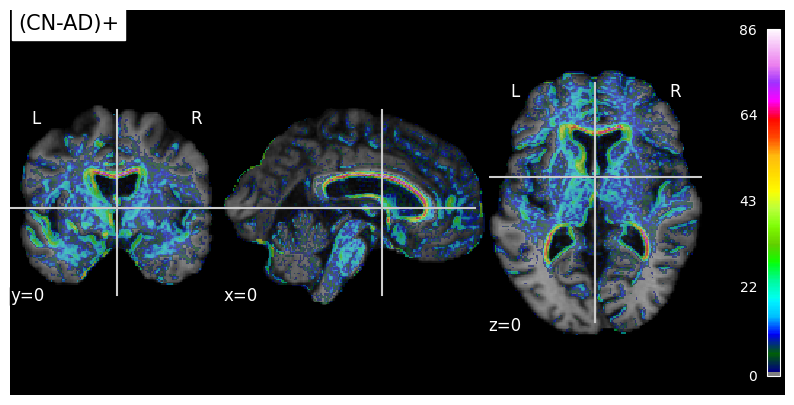

In [50]:
fig, axes = plt.subplots(figsize=(10, 5))

bg = nib.load(cn_std)
diff_pos = nib.load(str(base_dir / f'ground_truth_mask_{participant_id}.nii.gz'))
plotting.plot_roi(diff_pos, bg, threshold=0.0, axes=axes, alpha=0.5, cut_coords=(0, 0, 0), colorbar=True, title='(CN-AD)+')

## Exercise: Compare interpretation maps with anatomical differences

We now have two kinds of visual information:

1. **Interpretation maps** (e.g., Grad-CAM, Guided Backprop, MeanPerturb), which highlight regions that the model considers important for its prediction.  

2. **Difference map (CN − AD)**, which highlights structural differences between cognitively normal (CN) and Alzheimer’s Disease (AD) brains.  

### Task for students
    
   Overlay the **interpretation maps** on the MRI scans.  
   Overlay the **CN − AD difference map** on the same scans.  
   Compare the highlighted regions:  
      - Do the model’s saliency maps overlap with the regions where tissue loss is expected (hippocampus, ventricles, cortex)?  
      - Are there areas highlighted by the model but not by the simple subtraction, or vice versa?  

### Goal
This comparison helps to:
- Evaluate whether the model is focusing on clinically plausible regions.  
- Understand the difference between **model-driven interpretations** and **ground-truth anatomical differences**.  
- Discuss limitations: subtraction is a crude method, while interpretation maps depend on model biases and training data.  
